In [1]:
!pip install webdataset --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 4.4 MB/s eta 0:00:00


In [2]:
import sys, pathlib
ROOT = pathlib.Path('.').resolve().parent
sys.path.insert(0, str(ROOT / 'src'))

from config import mount_drive
mount_drive()

Mounted at /content/drive


# Experiment 04 - Transfer Learning

**Goal:** Evaluate pretrained ImageNet backbones vs the best scratch model.
**Strategy:** Two-phase training:
1. Freeze backbone, train head only for `freeze_epochs` epochs.
2. Unfreeze entire network, fine-tune at a lower LR.

**Backbones:** ResNet-18, ResNet-50, MobileNetV3-Small, EfficientNet-B0  
**Note:** MobileNetV3-Small is selected for real-time inference (lowest latency).

In [ ]:
import torch
import torch.nn as nn
from config import load_config
from augmentation import build_train_transform, build_eval_transform
from dataset import build_dataloaders
from model import TransferModel
from training import Trainer, compute_class_weights
from utils import set_seed, show_results, load_model, evaluate_model

cfg = load_config(ROOT / 'content/configs/config.yaml')
set_seed(cfg.preprocessing.random_seed, cfg.device)

num_classes = len(cfg.classes)
image_size = cfg.preprocessing.image_size
train_tf = build_train_transform(image_size, use_imagenet_norm=True)
eval_tf = build_eval_transform(image_size, use_imagenet_norm=True)

train_loader, val_loader, test_loader = build_dataloaders(
    train_transform=train_tf,
    eval_transform=eval_tf,
    **cfg.dataloader_kwargs(),
)

class_weights = compute_class_weights(cfg.class_weight_source, num_classes) if cfg.training.use_class_weights else None

FREEZE_EPOCHS = cfg.transfer.freeze_epochs
FINETUNE_EPOCHS = cfg.training.num_epochs - FREEZE_EPOCHS
print(f'Phase 1 (frozen): {FREEZE_EPOCHS} epochs')
print(f'Phase 2 (finetune): {FINETUNE_EPOCHS} epochs')

[config] environment: colab
Phase 1 (frozen):   5 epochs
Phase 2 (finetune): 25 epochs


In [ ]:
import json, time
import numpy as np

def run_transfer(backbone_name):
    exp_name = f'transfer_{backbone_name}'
    print(f'\n=== {backbone_name} ===')

    # Phase 1: frozen backbone
    model = TransferModel(backbone_name, num_classes=num_classes, freeze_backbone=True)
    trainer = Trainer(
        model=model, train_loader=train_loader, val_loader=val_loader,
        device=cfg.device, exp_name=exp_name + '_phase1',
        results_root=cfg.results_root, checkpoints_root=cfg.checkpoints_root,
        num_epochs=FREEZE_EPOCHS, learning_rate=1e-3,
        weight_decay=cfg.training.weight_decay, grad_clip=cfg.training.grad_clip,
        grad_accum_steps=cfg.training.grad_accum_steps,
        early_stopping_patience=FREEZE_EPOCHS + 1,
        use_amp=cfg.training.use_amp, scheduler='cosine',
        class_weights=class_weights, num_classes=num_classes,
        debug=cfg.debug,
    )
    history1 = trainer.train()

    # Phase 2: unfreeze and fine-tune
    model.unfreeze()
    trainer2 = Trainer(
        model=model, train_loader=train_loader, val_loader=val_loader,
        device=cfg.device, exp_name=exp_name,
        results_root=cfg.results_root, checkpoints_root=cfg.checkpoints_root,
        num_epochs=FINETUNE_EPOCHS, learning_rate=1e-4,
        weight_decay=cfg.training.weight_decay, grad_clip=cfg.training.grad_clip,
        grad_accum_steps=cfg.training.grad_accum_steps,
        early_stopping_patience=cfg.training.early_stopping_patience,
        use_amp=cfg.training.use_amp, scheduler='cosine',
        class_weights=class_weights, num_classes=num_classes,
        debug=cfg.debug,
    )
    history2 = trainer2.train()

    # Test evaluation
    best_ckpt = cfg.checkpoints_root / exp_name / 'best.pt'
    model = load_model(TransferModel(backbone_name, num_classes=num_classes, freeze_backbone=False), str(best_ckpt), cfg.device)
    test_loss, test_acc, f1, bal, true_l, pred_l = evaluate_model(model, test_loader, cfg.device, nn.CrossEntropyLoss())

    # Latency: single-image forward pass
    model.eval()
    dummy = torch.randn(1, 3, image_size, image_size).to(cfg.device)
    with torch.no_grad():
        for _ in range(10): model(dummy)  # warmup
        t0 = time.perf_counter()
        for _ in range(100): model(dummy)
        latency_ms = (time.perf_counter() - t0) / 100 * 1000

    print(f'{backbone_name:25s}  Macro-F1={f1:.4f}  Balanced-Acc={bal:.4f}  Latency={latency_ms:.2f}ms')

    results_dir = cfg.results_root / exp_name
    np.save(str(results_dir / 'y_true.npy'), np.array(true_l))
    np.save(str(results_dir / 'y_pred.npy'), np.array(pred_l))

    phase1_time_s = sum(history1['epoch_time_s'])
    phase2_time_s = sum(history2['epoch_time_s'])
    num_params_m = sum(p.numel() for p in model.parameters()) / 1e6

    test_summary = {
        'exp_name': exp_name,
        'model': backbone_name,
        'test_loss': round(test_loss, 6),
        'test_acc': round(test_acc, 6),
        'test_macro_f1': round(f1, 6),
        'test_balanced_acc': round(bal, 6),
        'inference_latency_ms': round(latency_ms, 3),
        'num_params_M': round(num_params_m, 2),
        'phase1_epochs': len(history1['train_loss']),
        'phase2_epochs': len(history2['train_loss']),
        'phase1_time_s': round(phase1_time_s, 1),
        'phase2_time_s': round(phase2_time_s, 1),
        'total_training_time_s': round(phase1_time_s + phase2_time_s, 1),
    }
    with open(results_dir / 'test_results.json', 'w') as f:
        json.dump(test_summary, f, indent=2)
    print(f'  Saved y_true.npy, y_pred.npy, test_results.json -> {results_dir}')

    return f1, latency_ms


=== resnet18 ===
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 180MB/s]



  Experiment: transfer_resnet18_phase1
  Device: cuda  |  AMP: True  |  Epochs: 5


Epoch 001/5  train_loss=3.8473  train_acc=0.0078  val_loss=3.6569  val_acc=0.0301  val_F1=0.0080  [379.4s]
  New best val macro-F1=0.0080 - checkpoint saved


Epoch 002/5  train_loss=3.7470  train_acc=0.0195  val_loss=3.5916  val_acc=0.0301  val_F1=0.0110  [53.1s]
  New best val macro-F1=0.0110 - checkpoint saved


Epoch 003/5  train_loss=3.6280  train_acc=0.0469  val_loss=3.5532  val_acc=0.0438  val_F1=0.0191  [15.9s]
  New best val macro-F1=0.0191 - checkpoint saved


Epoch 004/5  train_loss=3.6596  train_acc=0.0352  val_loss=3.5340  val_acc=0.0438  val_F1=0.0240  [8.3s]
  New best val macro-F1=0.0240 - checkpoint saved


Epoch 005/5  train_loss=3.6144  train_acc=0.0352  val_loss=3.5297  val_acc=0.0438  val_F1=0.0297  [4.9s]
  New best val macro-F1=0.0297 - checkpoint saved


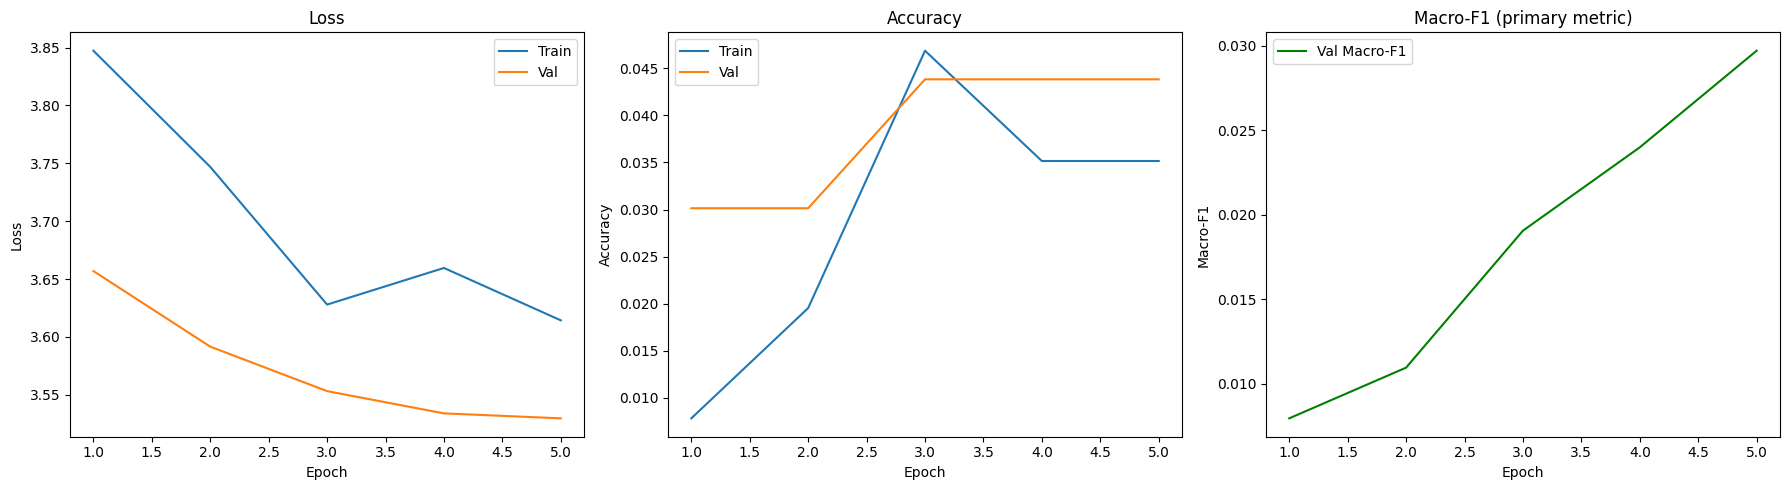


  Experiment: transfer_resnet18
  Device: cuda  |  AMP: True  |  Epochs: 25


Epoch 001/25  train_loss=3.6359  train_acc=0.0664  val_loss=3.3746  val_acc=0.0822  val_F1=0.0733  [6.9s]
  New best val macro-F1=0.0733 - checkpoint saved


Epoch 002/25  train_loss=3.3624  train_acc=0.1055  val_loss=3.2475  val_acc=0.1151  val_F1=0.1018  [4.6s]
  New best val macro-F1=0.1018 - checkpoint saved


Epoch 003/25  train_loss=3.1908  train_acc=0.1250  val_loss=3.1379  val_acc=0.1808  val_F1=0.1651  [5.5s]
  New best val macro-F1=0.1651 - checkpoint saved


Epoch 004/25  train_loss=3.0662  train_acc=0.1836  val_loss=3.0384  val_acc=0.1808  val_F1=0.1622  [5.3s]


...

Epoch 021/25  train_loss=1.6583  train_acc=0.6875  val_loss=2.1982  val_acc=0.5014  val_F1=0.4863  [7.4s]
  New best val macro-F1=0.4863 - checkpoint saved


Epoch 022/25  train_loss=1.6558  train_acc=0.7148  val_loss=2.1965  val_acc=0.5096  val_F1=0.4952  [4.8s]
  New best val macro-F1=0.4952 - checkpoint saved


Epoch 023/25  train_loss=1.6408  train_acc=0.6875  val_loss=2.1968  val_acc=0.5068  val_F1=0.4912  [5.6s]


Epoch 024/25  train_loss=1.6579  train_acc=0.7227  val_loss=2.1961  val_acc=0.5068  val_F1=0.4928  [5.1s]


Epoch 025/25  train_loss=1.6284  train_acc=0.7109  val_loss=2.1972  val_acc=0.5041  val_F1=0.4907  [7.6s]


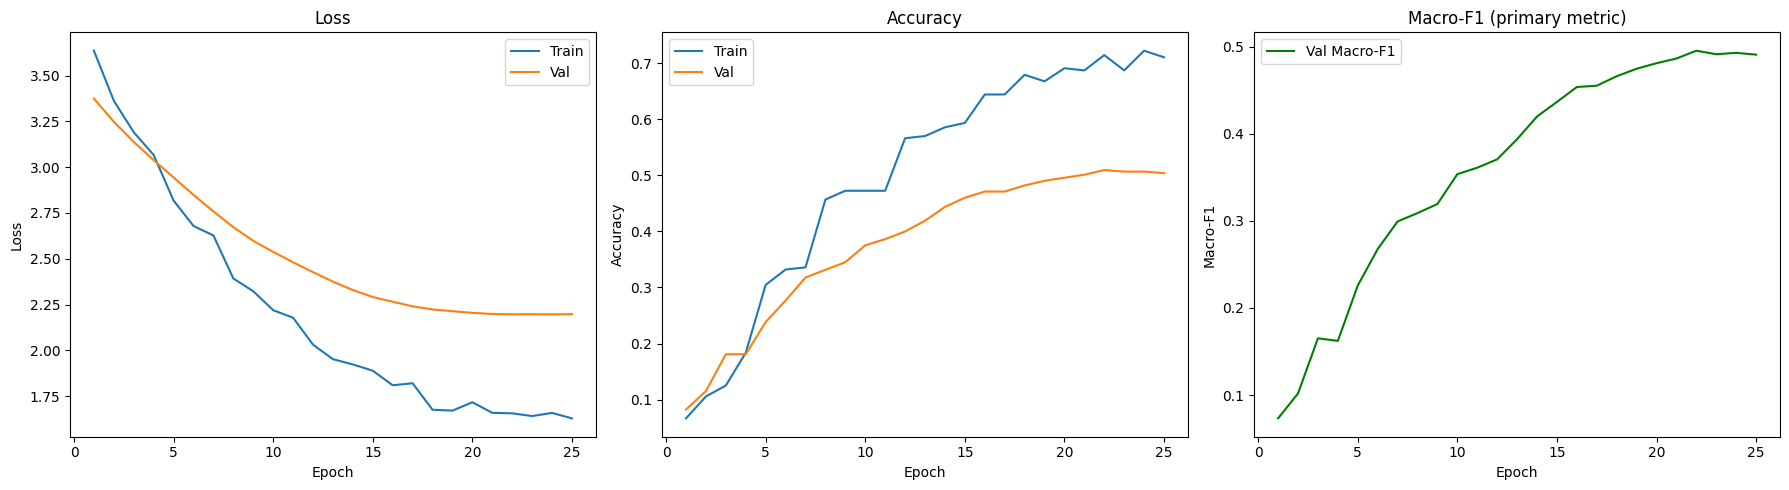

resnet18                   Macro-F1=0.3851  Balanced-Acc=0.4083  Latency=2.61ms

=== resnet50 ===
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 179MB/s]



  Experiment: transfer_resnet50_phase1
  Device: cuda  |  AMP: True  |  Epochs: 5


Epoch 001/5  train_loss=3.6049  train_acc=0.0430  val_loss=3.5535  val_acc=0.0438  val_F1=0.0230  [6.8s]
  New best val macro-F1=0.0230 - checkpoint saved


Epoch 002/5  train_loss=3.5432  train_acc=0.0547  val_loss=3.4972  val_acc=0.0493  val_F1=0.0273  [5.0s]
  New best val macro-F1=0.0273 - checkpoint saved


Epoch 003/5  train_loss=3.4849  train_acc=0.1016  val_loss=3.4538  val_acc=0.0767  val_F1=0.0572  [6.6s]
  New best val macro-F1=0.0572 - checkpoint saved


Epoch 004/5  train_loss=3.4277  train_acc=0.1562  val_loss=3.4325  val_acc=0.0959  val_F1=0.0800  [5.2s]
  New best val macro-F1=0.0800 - checkpoint saved


Epoch 005/5  train_loss=3.4235  train_acc=0.1602  val_loss=3.4278  val_acc=0.1068  val_F1=0.0875  [6.4s]
  New best val macro-F1=0.0875 - checkpoint saved


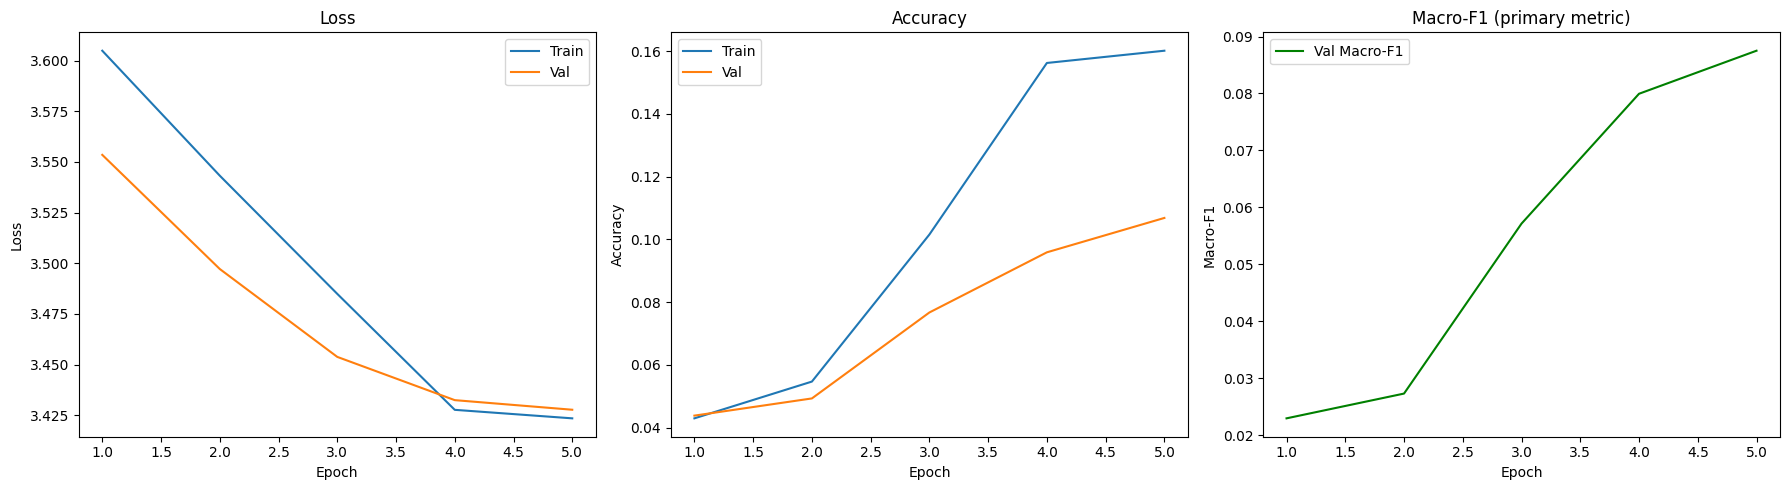


  Experiment: transfer_resnet50
  Device: cuda  |  AMP: True  |  Epochs: 25


Epoch 001/25  train_loss=3.3888  train_acc=0.1719  val_loss=3.3726  val_acc=0.1233  val_F1=0.0928  [5.6s]
  New best val macro-F1=0.0928 - checkpoint saved


Epoch 002/25  train_loss=3.2917  train_acc=0.2109  val_loss=3.3218  val_acc=0.1397  val_F1=0.1011  [7.1s]
  New best val macro-F1=0.1011 - checkpoint saved


Epoch 003/25  train_loss=3.2388  train_acc=0.1836  val_loss=3.2693  val_acc=0.1644  val_F1=0.1256  [6.6s]
  New best val macro-F1=0.1256 - checkpoint saved


Epoch 004/25  train_loss=3.1462  train_acc=0.2227  val_loss=3.2166  val_acc=0.1671  val_F1=0.1244  [6.5s]


...

Epoch 021/25  train_loss=2.1097  train_acc=0.5664  val_loss=2.5138  val_acc=0.3233  val_F1=0.3009  [5.6s]


Epoch 022/25  train_loss=2.0717  train_acc=0.5391  val_loss=2.5137  val_acc=0.3260  val_F1=0.3033  [11.0s]
  New best val macro-F1=0.3033 - checkpoint saved


Epoch 023/25  train_loss=2.0504  train_acc=0.5469  val_loss=2.5172  val_acc=0.3260  val_F1=0.3050  [6.9s]
  New best val macro-F1=0.3050 - checkpoint saved


Epoch 024/25  train_loss=2.0076  train_acc=0.5586  val_loss=2.5223  val_acc=0.3260  val_F1=0.3053  [6.3s]
  New best val macro-F1=0.3053 - checkpoint saved


Epoch 025/25  train_loss=2.0226  train_acc=0.6055  val_loss=2.5275  val_acc=0.3288  val_F1=0.3064  [6.9s]
  New best val macro-F1=0.3064 - checkpoint saved


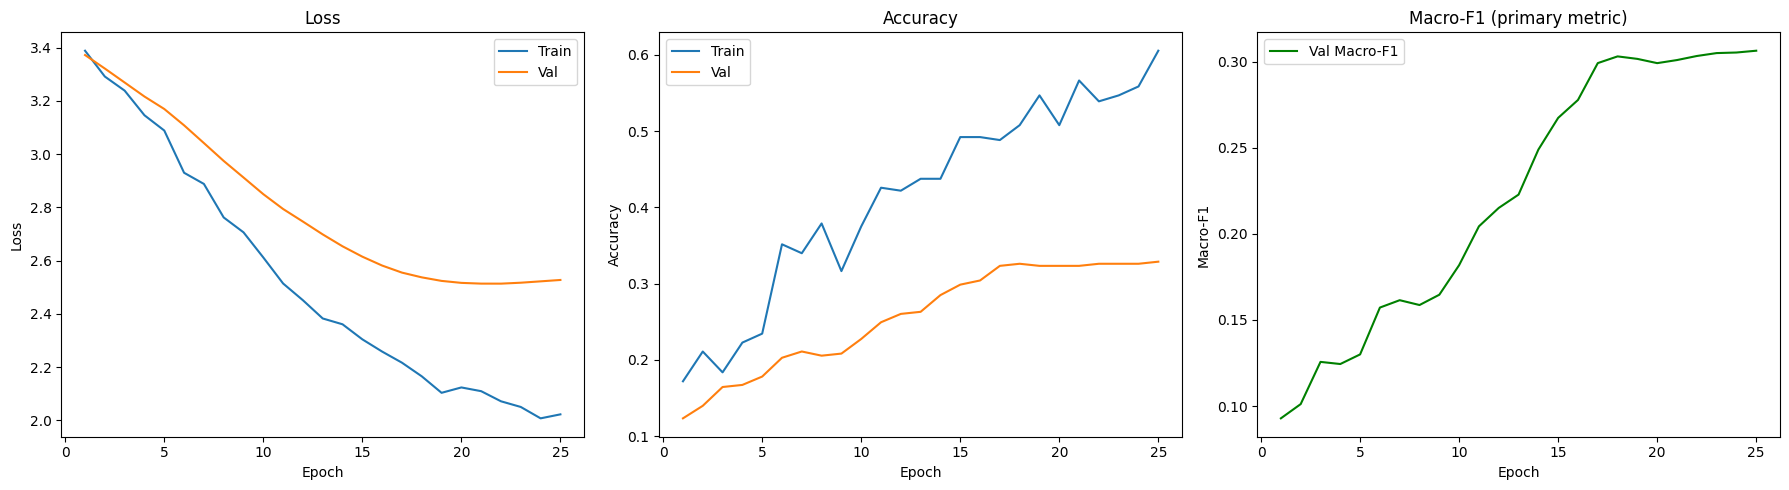

resnet50                   Macro-F1=0.3031  Balanced-Acc=0.3292  Latency=5.65ms

=== mobilenet_v3_small ===
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 131MB/s]



  Experiment: transfer_mobilenet_v3_small_phase1
  Device: cuda  |  AMP: True  |  Epochs: 5


Epoch 001/5  train_loss=3.6060  train_acc=0.0312  val_loss=3.5099  val_acc=0.0986  val_F1=0.0671  [13.6s]
  New best val macro-F1=0.0671 - checkpoint saved


Epoch 002/5  train_loss=3.3528  train_acc=0.0781  val_loss=3.4031  val_acc=0.1178  val_F1=0.0770  [4.3s]
  New best val macro-F1=0.0770 - checkpoint saved


Epoch 003/5  train_loss=3.1692  train_acc=0.2031  val_loss=3.3181  val_acc=0.1425  val_F1=0.0986  [5.4s]
  New best val macro-F1=0.0986 - checkpoint saved


Epoch 004/5  train_loss=2.9903  train_acc=0.2461  val_loss=3.2719  val_acc=0.1562  val_F1=0.1115  [4.8s]
  New best val macro-F1=0.1115 - checkpoint saved


Epoch 005/5  train_loss=2.9219  train_acc=0.3047  val_loss=3.2562  val_acc=0.1644  val_F1=0.1148  [4.3s]
  New best val macro-F1=0.1148 - checkpoint saved


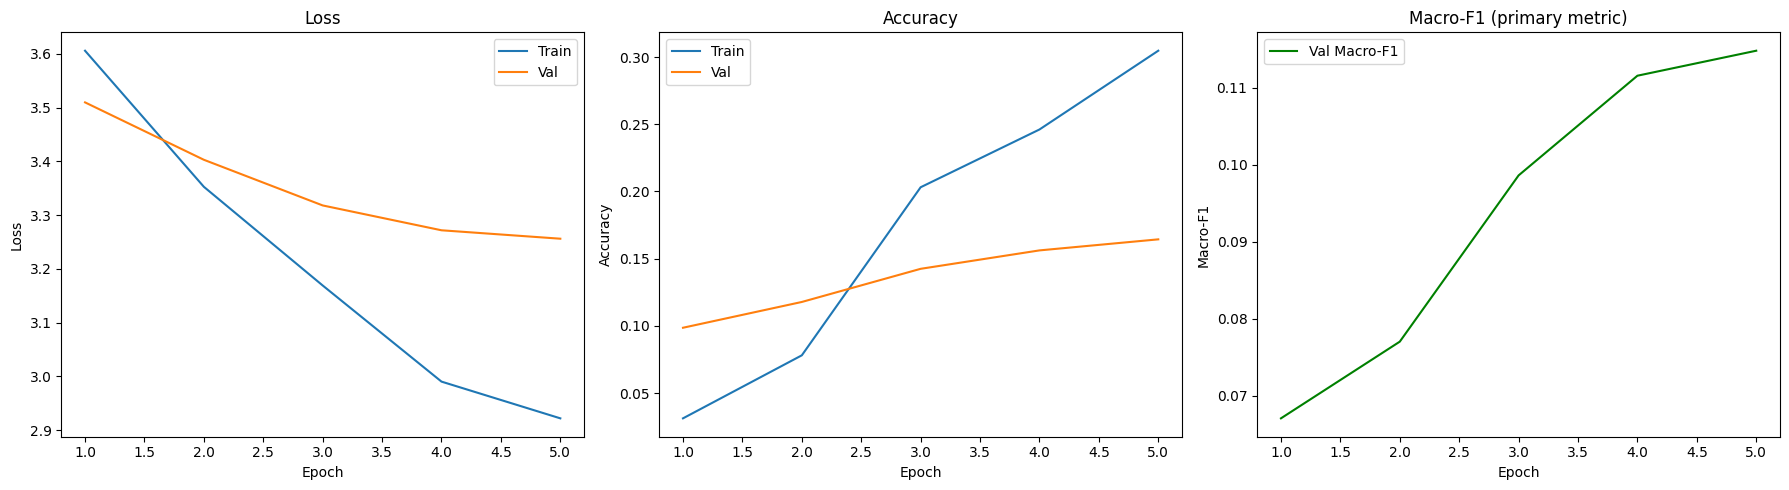


  Experiment: transfer_mobilenet_v3_small
  Device: cuda  |  AMP: True  |  Epochs: 25


Epoch 001/25  train_loss=2.9059  train_acc=0.2891  val_loss=3.2263  val_acc=0.1836  val_F1=0.1301  [8.4s]
  New best val macro-F1=0.1301 - checkpoint saved


Epoch 002/25  train_loss=2.8685  train_acc=0.2891  val_loss=3.1963  val_acc=0.1918  val_F1=0.1363  [4.5s]
  New best val macro-F1=0.1363 - checkpoint saved


Epoch 003/25  train_loss=2.8691  train_acc=0.2773  val_loss=3.1642  val_acc=0.2055  val_F1=0.1504  [5.6s]
  New best val macro-F1=0.1504 - checkpoint saved


Epoch 004/25  train_loss=2.7763  train_acc=0.3086  val_loss=3.1325  val_acc=0.2055  val_F1=0.1505  [4.4s]
  New best val macro-F1=0.1505 - checkpoint saved


...

Epoch 021/25  train_loss=2.3024  train_acc=0.4297  val_loss=2.7984  val_acc=0.2712  val_F1=0.2144  [4.9s]


Epoch 022/25  train_loss=2.3901  train_acc=0.4375  val_loss=2.7912  val_acc=0.2740  val_F1=0.2176  [4.4s]
  New best val macro-F1=0.2176 - checkpoint saved


Epoch 023/25  train_loss=2.4256  train_acc=0.4258  val_loss=2.7847  val_acc=0.2767  val_F1=0.2148  [5.7s]


Epoch 024/25  train_loss=2.4147  train_acc=0.4023  val_loss=2.7790  val_acc=0.2795  val_F1=0.2195  [4.5s]
  New best val macro-F1=0.2195 - checkpoint saved


Epoch 025/25  train_loss=2.4263  train_acc=0.4062  val_loss=2.7740  val_acc=0.2822  val_F1=0.2224  [4.5s]
  New best val macro-F1=0.2224 - checkpoint saved


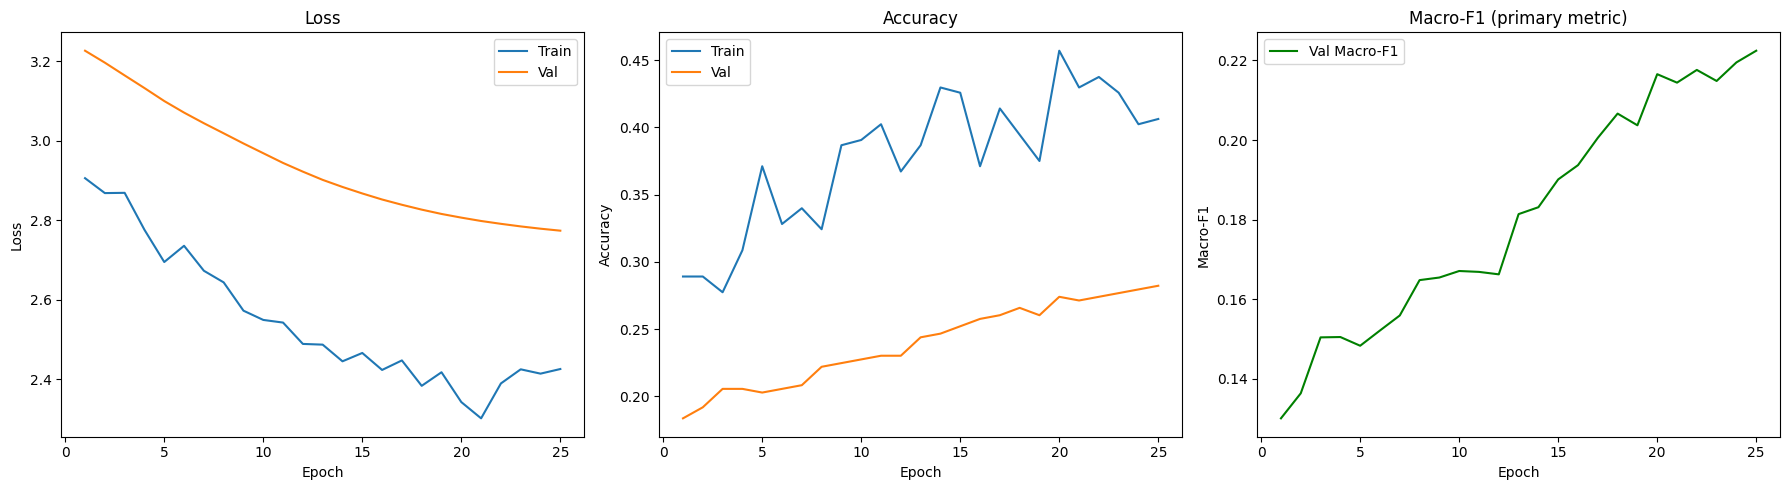

mobilenet_v3_small         Macro-F1=0.2318  Balanced-Acc=0.2968  Latency=7.63ms

=== efficientnet_b0 ===
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 117MB/s]



  Experiment: transfer_efficientnet_b0_phase1
  Device: cuda  |  AMP: True  |  Epochs: 5


Epoch 001/5  train_loss=3.6158  train_acc=0.0234  val_loss=3.5509  val_acc=0.0712  val_F1=0.0433  [11.9s]
  New best val macro-F1=0.0433 - checkpoint saved


Epoch 002/5  train_loss=3.5282  train_acc=0.0898  val_loss=3.4876  val_acc=0.0932  val_F1=0.0667  [6.3s]
  New best val macro-F1=0.0667 - checkpoint saved


Epoch 003/5  train_loss=3.4276  train_acc=0.1367  val_loss=3.4347  val_acc=0.1288  val_F1=0.0937  [4.8s]
  New best val macro-F1=0.0937 - checkpoint saved


Epoch 004/5  train_loss=3.3145  train_acc=0.1484  val_loss=3.4005  val_acc=0.1370  val_F1=0.1066  [6.3s]
  New best val macro-F1=0.1066 - checkpoint saved


Epoch 005/5  train_loss=3.3243  train_acc=0.1758  val_loss=3.3824  val_acc=0.1288  val_F1=0.1010  [4.8s]


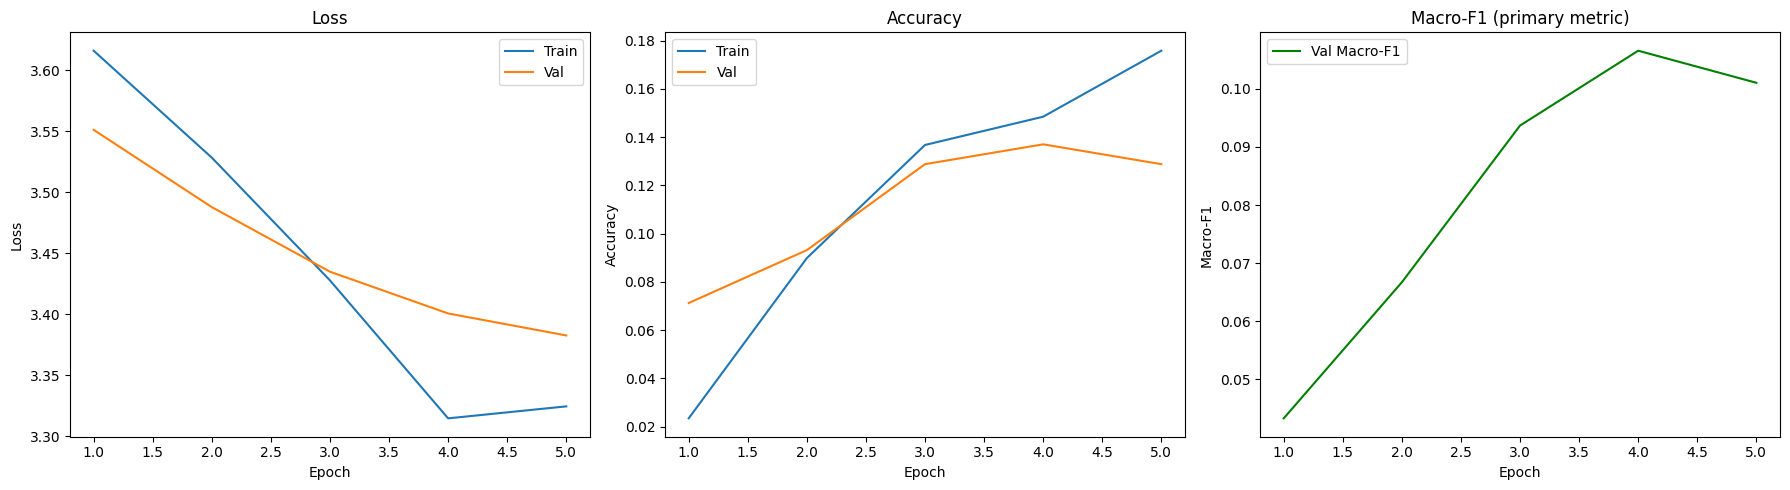


  Experiment: transfer_efficientnet_b0
  Device: cuda  |  AMP: True  |  Epochs: 25


Epoch 001/25  train_loss=3.3190  train_acc=0.1641  val_loss=3.3413  val_acc=0.1452  val_F1=0.1136  [9.2s]
  New best val macro-F1=0.1136 - checkpoint saved


Epoch 002/25  train_loss=3.2360  train_acc=0.2227  val_loss=3.2951  val_acc=0.1616  val_F1=0.1315  [4.9s]
  New best val macro-F1=0.1315 - checkpoint saved


Epoch 003/25  train_loss=3.2080  train_acc=0.2344  val_loss=3.2504  val_acc=0.1753  val_F1=0.1398  [5.6s]
  New best val macro-F1=0.1398 - checkpoint saved


Epoch 004/25  train_loss=3.1448  train_acc=0.2383  val_loss=3.2087  val_acc=0.1890  val_F1=0.1537  [6.0s]
  New best val macro-F1=0.1537 - checkpoint saved


...

Epoch 021/25  train_loss=2.7095  train_acc=0.4453  val_loss=2.9195  val_acc=0.3178  val_F1=0.2932  [6.3s]


Epoch 022/25  train_loss=2.7277  train_acc=0.4609  val_loss=2.9187  val_acc=0.3178  val_F1=0.2931  [4.8s]


Epoch 023/25  train_loss=2.7060  train_acc=0.4062  val_loss=2.9204  val_acc=0.3178  val_F1=0.2957  [5.2s]


Epoch 024/25  train_loss=2.7378  train_acc=0.4453  val_loss=2.9215  val_acc=0.3178  val_F1=0.2940  [6.3s]


Epoch 025/25  train_loss=2.7167  train_acc=0.4531  val_loss=2.9224  val_acc=0.3123  val_F1=0.2890  [5.1s]
  Early stopping triggered at epoch 25.


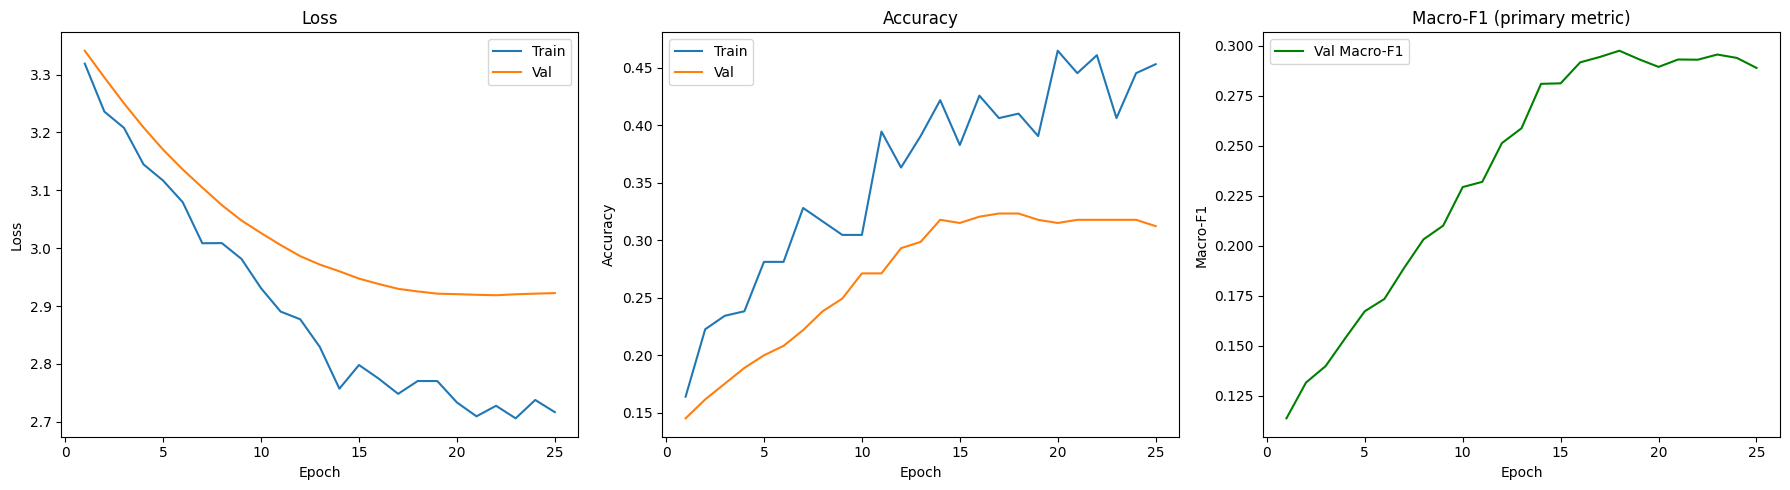

efficientnet_b0            Macro-F1=0.2280  Balanced-Acc=0.2381  Latency=11.26ms

--- Transfer Learning Summary ---
                    macro_f1  latency_ms
resnet18            0.385074    2.610296
resnet50            0.303073    5.645774
mobilenet_v3_small  0.231796    7.631856
efficientnet_b0     0.228030   11.257310


In [5]:
results = {}
for backbone in cfg.transfer.backbones:
    f1, lat = run_transfer(backbone)
    results[backbone] = {'macro_f1': f1, 'latency_ms': lat}

import pandas as pd
res_df = pd.DataFrame(results).T
print('\n--- Transfer Learning Summary ---')
print(res_df.sort_values('macro_f1', ascending=False).to_string())